## HW5

In [32]:
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV,StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, make_scorer, matthews_corrcoef
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd


#### Loading Data

In [33]:
data = pd.read_csv('HW05_data.csv')
data.head()

X = data.drop('Y',axis=1)
y = data['Y']
y.value_counts()

#print(X.shape)
#print(X.head())
#print(y.shape)

Y
benign       357
malignant    212
Name: count, dtype: int64

#### Preprocessing

In [34]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
scaler = StandardScaler()
rs = 42

#print(encoder.classes_)
#print(y_encoded.shape)
#print(X.shape)
(x_train, x_test, y_train, y_test) = train_test_split(np.asarray(X), y_encoded, test_size=0.25, random_state=rs, stratify=y_encoded)
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
print(pd.DataFrame(y_test).value_counts())
print(pd.DataFrame(y_train).value_counts())
#print(x_train.shape)
#print(x_test.shape)


0
0    90
1    53
Name: count, dtype: int64
0
0    267
1    159
Name: count, dtype: int64


#### Training

##### Search for Optimal K, p, and Weights Parameters based on GridSearchCV

In [35]:
#All Gathered from AML_s26_knn.ipynb and slightly modified for this dataset
#Identify Best K, P, and Weights to use on KNN Classifier (from K=1 to K=30, P: 1- 5, and both uniform and distance weights)

knn = KNeighborsClassifier()
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=rs)
param_grid = {
    'n_neighbors': list(range(1, 31)),
    'weights': ['uniform', 'distance'],
    'p' : [1, 2,3,4,5]  # 1 for Manhattan distance, 2 for Euclidean, 3,4,5 for higher order
}
# Run GridSearchCV to find the best parameters based on f1 score as it is a better average metric for datasets

grid = GridSearchCV(knn, param_grid, cv=kfold, scoring='f1', n_jobs=-1)
grid.fit(x_train, y_train)

best_k = grid.best_params_['n_neighbors']
best_weight = grid.best_params_['weights']
best_p = grid.best_params_['p']
print(f"Best K: {best_k}, Best Weight: {best_weight}, Best P: {best_p}")


Best K: 3, Best Weight: uniform, Best P: 1


##### KNN model based off of 5-fold cross-val

In [36]:

#Define Fold with 5 splits, shuffling, and a fixed random state. 
#Chose 5 since this is most common with a data set of this size, and provides a good balance.


model = KNeighborsClassifier(n_neighbors=best_k, weights='uniform', p=1)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
error = np.mean(y_test != y_pred)
print(f"Test Error with K={best_k}, Weight={best_weight}, P={best_p}: {error:.4f}")


Test Error with K=3, Weight=uniform, P=1: 0.0280


#### Evaluation

              precision    recall  f1-score   support

      benign       0.96      1.00      0.98        90
   malignant       1.00      0.92      0.96        53

    accuracy                           0.97       143
   macro avg       0.98      0.96      0.97       143
weighted avg       0.97      0.97      0.97       143

[[90  0]
 [ 4 49]]


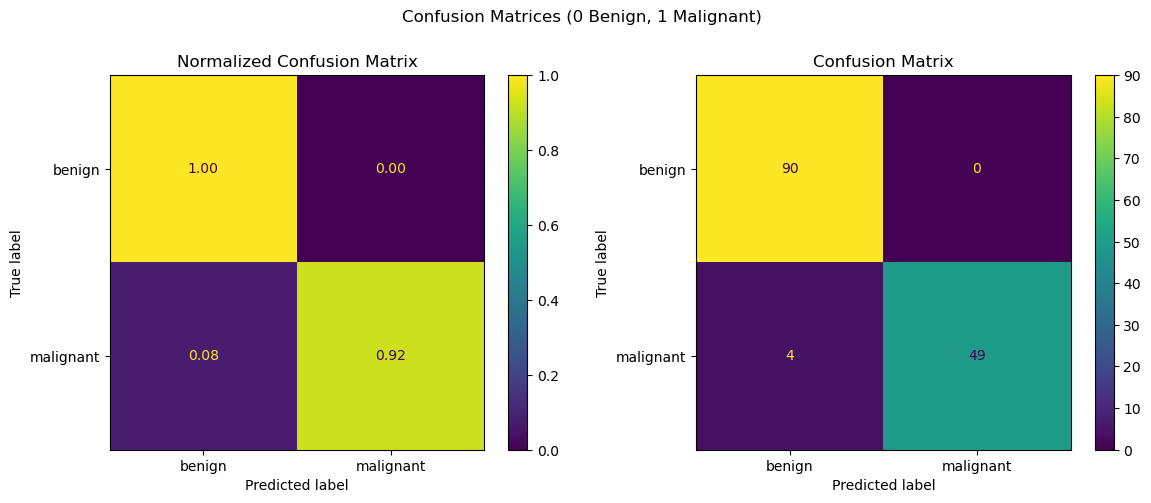

In [37]:
print(classification_report(y_test, y_pred, target_names=encoder.classes_))
cm = confusion_matrix(y_test, y_pred)
print(cm)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Normalized confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=encoder.classes_,
    normalize="true", values_format=".2f", ax=axes[0]
)
axes[0].set_title("Normalized Confusion Matrix")

# Non-normalized confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=encoder.classes_, ax=axes[1]
)
axes[1].set_title("Confusion Matrix")

plt.suptitle("Confusion Matrices (0 Benign, 1 Malignant)")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("knn_confusion_matrix.png", dpi=300)
plt.show()

